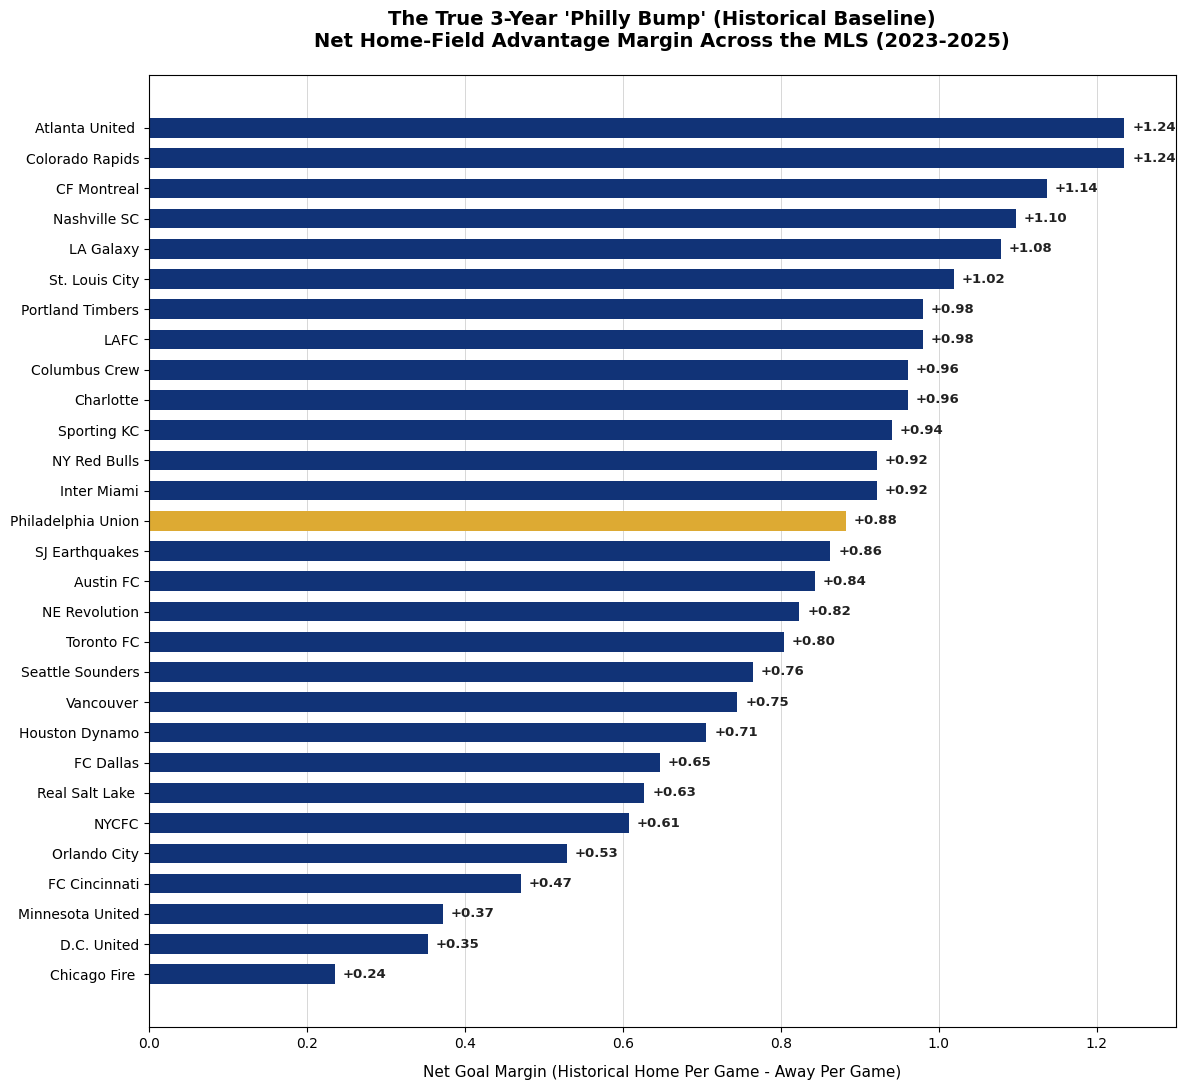

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data from the uploaded CSV file with no header initially
#    The actual headers are in the second row (index 1) of the CSV file.
df_raw = pd.read_csv('mls_home_away_data.csv', header=None)

# Set the column names from the second row
df_raw.columns = df_raw.iloc[1]

# Drop the first two rows (the blank row and the row that became headers)
df = df_raw[2:].reset_index(drop=True)

# 2. Filter out San Diego FC (since they only played 2025 and aren't in 3-year baseline)
df = df[df['Team'] != 'San Diego FC']

# Convert relevant columns to numeric, coercing errors to NaN
# This ensures that mathematical operations can be performed correctly
numeric_cols = ['Home_GF', 'Home_GA', 'Home_MP', 'Away_GF', 'Away_GA', 'Away_MP']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop any rows that might have become all NaN in critical columns after conversion
# Use the subset of columns used in calculations
df.dropna(subset=['Team', 'Home_GF', 'Home_GA', 'Home_MP', 'Away_GF', 'Away_GA', 'Away_MP'], inplace=True)

# 3. Aggregate metrics over the 3-year historical timeframe (2023-2025)
grouped = df.groupby('Team').sum(numeric_only=True).reset_index()

# 4. Calculate Net Home-Field Advantage Margin per game
# Formula: (Home Goals For - Home Goals Against) / Home Matches Played
#          - (Away Goals For - Away Goals Against) / Away Matches Played
grouped['Home_Margin_PG'] = (grouped['Home_GF'] - grouped['Home_GA']) / grouped['Home_MP']
grouped['Away_Margin_PG'] = (grouped['Away_GF'] - grouped['Away_GA']) / grouped['Away_MP']
grouped['Net_HFA_Margin'] = grouped['Home_Margin_PG'] - grouped['Away_Margin_PG']

# Sort the dataset ascendingly so the highest team plots at the top of the horizontal bar chart
grouped = grouped.sort_values(by='Net_HFA_Margin', ascending=True)

# 5. Build and Style the Plot
fig, ax = plt.subplots(figsize=(12, 11))

# Define colors
colors = ['#DDAA33' if team == 'Philadelphia Union' else '#113377' for team in grouped['Team']]

# Plot horizontal bars
bars = ax.barh(grouped['Team'], grouped['Net_HFA_Margin'], color=colors, height=0.65)

# Set custom chart title and axis labels
ax.set_title("The True 3-Year 'Philly Bump' (Historical Baseline)\nNet Home-Field Advantage Margin Across the MLS (2023-2025)",
             fontsize=14, pad=20, fontweight='bold', family='sans-serif')
ax.set_xlabel("Net Goal Margin (Historical Home Per Game - Away Per Game)", fontsize=11, labelpad=10)

# Add gridlines on the X-axis
ax.grid(axis='x', linestyle='-', linewidth=0.5, alpha=0.7)
ax.set_axisbelow(True)

# Adjust axes limits and tick styling
ax.set_xlim(0.0, 1.3)
ax.tick_params(axis='both', labelsize=10)

# Add positive sign to the end of each bar
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.01, bar.get_y() + bar.get_height()/2, f"+{width:.2f}",
            va='center', ha='left', fontsize=9.5, fontweight='bold', color='#222222')

# Fine-tune layout margins
plt.tight_layout()

# Save as an image file
plt.savefig('philly_bump_baseline_chart.png', dpi=300, bbox_inches='tight')

# Display the final plot output
plt.show()